# xlpe_discrete_layers: expediente PINN–FEniCSx

Este cuaderno revisa resultados calculados de un problema físico común. Las
opciones `RUN_FEM` y `RUN_PINN` permiten recalcularlo. La ejecución guardada del
cuaderno carga los artefactos existentes; los entrenamientos y las soluciones
FEM se realizaron con los scripts indicados en sus metadatos.

Las comparaciones de cables usan un dominio de suelo con flujo circular
uniforme y reconstrucción radial de la temperatura del conductor. Los datos
de Aras y Kim se adaptan a condiciones controladas; no se reproduce exactamente
el experimento publicado ni se demuestra validación de campo.

## 1. Datos y trazabilidad

## Fundamento y procedencia

El entrenamiento mediante residuos y diferenciación automática se fundamenta en la versión consultada de Raissi et al. (2017: 4–5). La verificación del cálculo térmico sigue la distinción entre verificación y validación de CIGRÉ Working Group B1.87 (2025: 93–99). La comparación de pesos responde a dificultades de optimización documentadas por Wang et al. (2020: 9–10); no se implementa ni se atribuye a la campaña su algoritmo adaptativo. La implementación FEM utiliza DOLFINx, cuyo entorno de solución y relación con FEniCSx describen Baratta et al. (2023: 1–3). Las versiones de software efectivamente ejecutadas se registran aparte. La separación entre capacidad, muestreo y optimización sigue De Ryck y Mishra (2024: 24–27, 51–57). Las cotas que relacionan error, estabilidad y cuadratura requieren hipótesis específicas (Mishra y Molinaro, 2020: 7–8); las pendientes observadas en esta batería no se presentan como órdenes teóricos de PINN. La solución manufacturada o el escenario XLPE específico es de elaboración propia; sus valores no se atribuyen a un experimento publicado. La resistencia DC se actualiza con la temperatura individual del conductor, siguiendo la ley lineal y el coeficiente del cobre documentados en CIGRÉ Working Group B1.56 (2022: 132). Las pérdidas AC adicionales de esa fuente quedan fuera del modelo DC ejecutado. La continuidad entre subredes se relaciona con Shukla et al. (2021: 1, 5–6, paginación de la versión arXiv consultada).

Las páginas corresponden a la versión identificada en las referencias. Se usa el formato de cita solicitado: autor, año: página.

In [1]:
from pathlib import Path
import sys, json, hashlib, subprocess, platform
import numpy as np
import pandas as pd
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p/'Benchmarks/cases.py').exists())
sys.path.insert(0, str(ROOT))
from Benchmarks.cases import cases, fingerprint, field_k
from Benchmarks.report import records, selected_directory, selected_ampacity_directory, plot_case
def show_figure(fig):
    from io import BytesIO
    from IPython.display import display, Image
    buffer=BytesIO()
    fig.savefig(buffer,format='png',dpi=140,bbox_inches='tight')
    display(Image(data=buffer.getvalue()))
CASE = 'xlpe_discrete_layers'
c = cases()[CASE]
print(json.dumps(c, ensure_ascii=False, indent=2))
print('SHA-256 de la especificación:', fingerprint(c))

{
  "id": "xlpe_discrete_layers",
  "kind": "cable",
  "bounds": [
    -4.0,
    4.0,
    -4.0,
    0.0
  ],
  "T0": 20.0,
  "scale": 50.0,
  "cables": [
    [
      0.0,
      -0.7
    ]
  ],
  "radius": 0.015,
  "layers": [
    [
      0,
      0.0055,
      400
    ],
    [
      0.0055,
      0.012,
      0.286
    ],
    [
      0.012,
      0.013,
      380
    ],
    [
      0.013,
      0.015,
      0.45
    ]
  ],
  "power": 14.069700000000001,
  "current": 270.0,
  "R20": 0.000193,
  "alpha": 0.00393,
  "k": 1.0,
  "patch": null,
  "bands": [],
  "pair": "xlpe_single",
  "source": "examples/xlpe_single_cable/data",
  "adaptation": "Dos estratos exactos de suelo: k=0.5 bajo y=-1 m y k=1 sobre la interfaz; sin suavizado.",
  "conductivity": {
    "type": "layers",
    "axis": "y",
    "interfaces": [
      -1.0
    ],
    "values": [
      0.5,
      1.0
    ],
    "smoothing": 0.0
  }
}
SHA-256 de la especificación: b17c05d5f03b22aff39ce94d6f1c1180478d14b9f87fdacd6a514736eb6e3

## 2. Ecuación, fuentes y fronteras

Se resuelve $-\nabla\cdot(k\nabla T)=Q$. En el suelo de los casos de cables,
$Q=0$ y cada frontera circular recibe $P_j=I^2R_{20}[1+\alpha(T_{c,j}-20)]$ W/m.
La ley de resistencia DC y el coeficiente del cobre se contrastan con CIGRÉ
Working Group B1.56 (2022: 132). Los ensayos identificados como `fixed_source`
conservan $I^2R_{20}$ únicamente como verificación térmica controlada.
Las normales apuntan hacia fuera del suelo; su flujo es $-P_j/(2\pi r)$.
En las soluciones manufacturadas, `exact` y `source` definen una identidad
analítica comprobada por pruebas independientes. El residuo se diferencia
automáticamente, siguiendo Raissi et al. (2017: 4–5); para k variable incluye
$\nabla k\cdot\nabla T$.

## 3. Recalcular ambos métodos

FEM emplea tres mallas P2, como comprobación de discretización coherente con
CIGRÉ Working Group B1.87 (2025: 93–99). PINN no utiliza temperaturas FEM para entrenar.
Se recomienda asignar otro directorio de salida para una nueva campaña.

In [2]:
RUN_FEM = False
RUN_PINN = False
FENICS_PYTHON = '/home/lkoc/miniforge3/envs/fenicsx/bin/python'
if RUN_FEM:
    fem_script='fem_coupled.py' if c['kind']=='cable' else 'fem.py'
    if platform.system() == 'Windows':
        linux_script = '/mnt/' + ROOT.drive[0].lower() + str(ROOT/'Benchmarks'/fem_script)[2:].replace('\\','/')
        cmd = ['wsl','-d','Ubuntu','--',FENICS_PYTHON,linux_script,'--cases',CASE,'--levels','0','1','2']
    else:
        cmd = [FENICS_PYTHON,str(ROOT/'Benchmarks'/fem_script),'--cases',CASE,'--levels','0','1','2']
    subprocess.run(cmd,cwd=ROOT,check=True)
if RUN_PINN:
    saved = sorted(selected_directory(CASE).glob('pinn_seed*.json'))[0]
    m = json.loads(saved.read_text())['metadata']
    cfg = dict(m['configuration'])
    cfg.update(cases=[CASE],seeds=[11,23,37],output='Benchmarks/reproduced')
    path=ROOT/'Benchmarks/notebooks'/f'{CASE}_rerun.json'
    path.write_text(json.dumps(cfg,indent=2),encoding='utf-8')
    subprocess.run([sys.executable,str(ROOT/'Benchmarks/pinn.py'),'--config',str(path)],cwd=ROOT,check=True)
print('Consulta de artefactos existentes; activar las opciones anteriores para recalcular.')

Consulta de artefactos existentes; activar las opciones anteriores para recalcular.


## 4. Convergencia FEM

In [3]:
mesh=[]
for level in [0,1,2]:
    family='coupled_results' if c['kind']=='cable' else 'results'
    r=json.loads((ROOT/'Benchmarks'/family/CASE/f'fem_l{level}.json').read_text())
    assert r['case_sha256']==fingerprint(c)
    mesh.append({k:r[k] for k in ['level','ndofs','Tmax_C','balance_pct','elapsed_s','dolfinx']})
display(pd.DataFrame(mesh))

,level,ndofs,Tmax_C,balance_pct,elapsed_s,dolfinx
0,0,850,38.633066,1.845590,1.641801,0.10.0
1,1,3217,38.650774,1.084451,3.471029,0.10.0
2,2,11643,38.651791,0.288435,5.690394,0.10.0


## 5. Comparación de todas las variantes y semillas

NRMSE ≤ 5 %, error del incremento máximo ≤ 5 % y balance ≤ 2 % constituyen
la puerta térmica. Los residuos locales y errores máximos se reportan
adicionalmente; cumplir el balance global no garantiza la solución local.

In [4]:
df=pd.DataFrame([r for r in records() if r['case']==CASE])
display(df[['run','mode','variant','sampling','width','depth','seed','rmse_fem_K','nrmse_fem_pct','error_Tmax_rise_pct','balance_pct','thermal_criteria_pass']])

,run,mode,variant,sampling,width,depth,seed,rmse_fem_K,nrmse_fem_pct,error_Tmax_rise_pct,balance_pct,thermal_criteria_pass
0,ampacity_final/xlpe_discrete_layers,ampacity,multipole,fixed,32,3,11,0.130987,0.187124,0.028509,0.000753,True
1,ampacity_final/xlpe_discrete_layers,ampacity,multipole,fixed,32,3,23,0.100121,0.143031,0.021419,0.001680,True
2,ampacity_final/xlpe_discrete_layers,ampacity,multipole,fixed,32,3,37,0.113093,0.161561,0.021323,0.002144,True
3,comparisons/final_discrete/xlpe_discrete_layers,fixed_source,conservative,fixed,32,3,11,0.046774,0.269159,0.603098,0.005083,True
4,comparisons/final_discrete/xlpe_discrete_layers,fixed_source,conservative,fixed,32,3,23,0.048950,0.281676,0.879982,0.001393,True
5,comparisons/final_discrete/xlpe_discrete_layers,fixed_source,conservative,fixed,32,3,37,0.051741,0.297738,0.603908,0.006567,True
6,coupled_final/xlpe_discrete_layers,coupled,multipole,fixed,32,3,11,0.046061,0.246951,0.042298,0.000033,True
7,coupled_final/xlpe_discrete_layers,coupled,multipole,fixed,32,3,23,0.073839,0.395882,0.377869,0.003265,True
8,coupled_final/xlpe_discrete_layers,coupled,multipole,fixed,32,3,37,0.048077,0.257763,0.441168,0.002843,True


## 6. Campos sobre los mismos puntos de evaluación

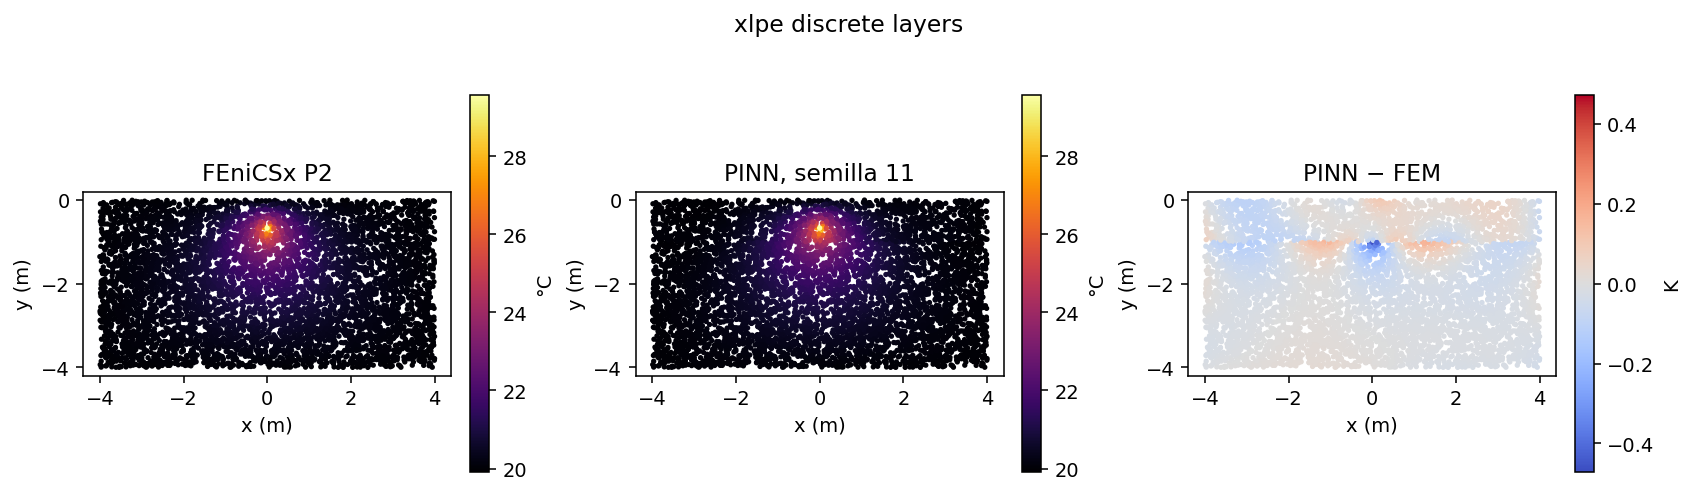

In [5]:
import matplotlib.pyplot as plt
fig=plot_case(CASE)
show_figure(fig)
plt.close(fig)

## 7. Entrenamiento y procedencia

,case_sha256,seed,torch,python,platform,device,dtype,threads,width,depth,...,final_loss,training_parts,fem_labels_used,variant,coupled,ampacity,temperature_limit_C,loss_model,configuration,source_sha256
0,b17c05d5f03b22aff39ce94d6f1c1180478d14b9f87fda...,11,2.9.0+xpu,"3.12.9 (tags/v3.12.9:fdb8142, Feb 4 2025, 15:...",Windows-11-10.0.26100-SP0,cpu,float64,1,32,3,...,0.000858,"{'pde': 7.750058206260546e-06, 'bc': 2.1765305...",0,multipole,True,False,90.0,"{'type': 'dc_linear_temperature', 'reference_t...","{'cases': ['xlpe_discrete_layers'], 'seeds': [...",{'Benchmarks\pinn.py': '5705aa1d5252ba16dc3697...


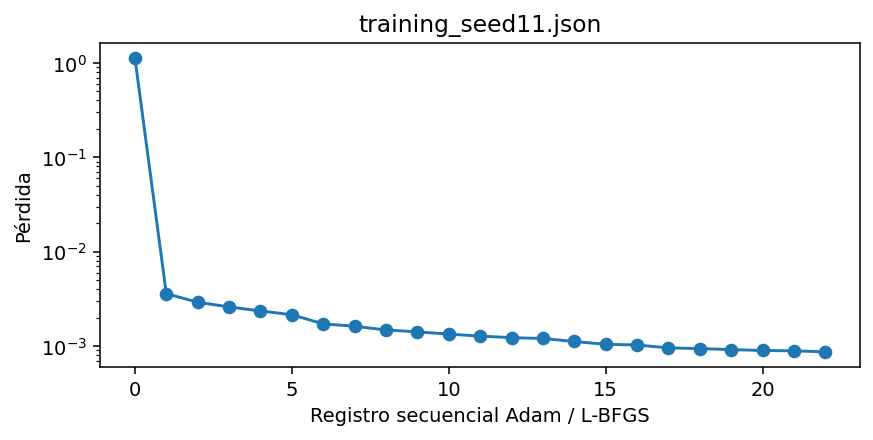

,case_sha256,seed,torch,python,platform,device,dtype,threads,width,depth,...,final_loss,training_parts,fem_labels_used,variant,coupled,ampacity,temperature_limit_C,loss_model,configuration,source_sha256
0,b17c05d5f03b22aff39ce94d6f1c1180478d14b9f87fda...,23,2.9.0+xpu,"3.12.9 (tags/v3.12.9:fdb8142, Feb 4 2025, 15:...",Windows-11-10.0.26100-SP0,cpu,float64,1,32,3,...,0.000898,"{'pde': 1.0216477003095045e-05, 'bc': 2.958216...",0,multipole,True,False,90.0,"{'type': 'dc_linear_temperature', 'reference_t...","{'cases': ['xlpe_discrete_layers'], 'seeds': [...",{'Benchmarks\pinn.py': '5705aa1d5252ba16dc3697...


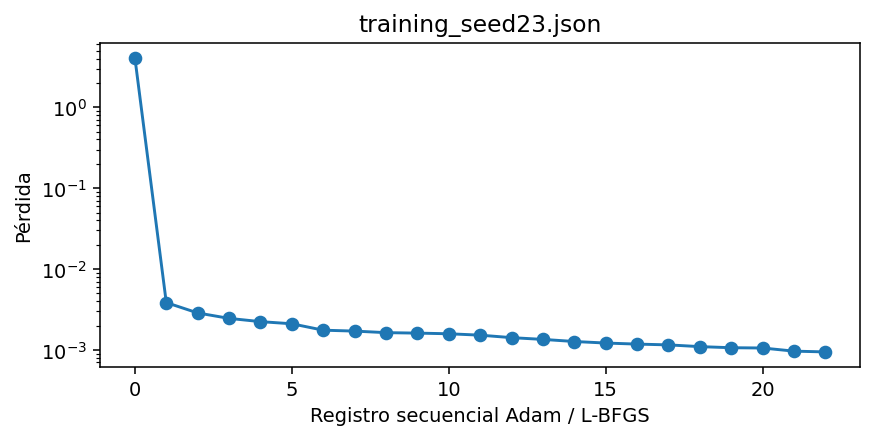

,case_sha256,seed,torch,python,platform,device,dtype,threads,width,depth,...,final_loss,training_parts,fem_labels_used,variant,coupled,ampacity,temperature_limit_C,loss_model,configuration,source_sha256
0,b17c05d5f03b22aff39ce94d6f1c1180478d14b9f87fda...,37,2.9.0+xpu,"3.12.9 (tags/v3.12.9:fdb8142, Feb 4 2025, 15:...",Windows-11-10.0.26100-SP0,cpu,float64,1,32,3,...,0.000794,"{'pde': 5.3177554731726235e-06, 'bc': 2.705701...",0,multipole,True,False,90.0,"{'type': 'dc_linear_temperature', 'reference_t...","{'cases': ['xlpe_discrete_layers'], 'seeds': [...",{'Benchmarks\pinn.py': '5705aa1d5252ba16dc3697...


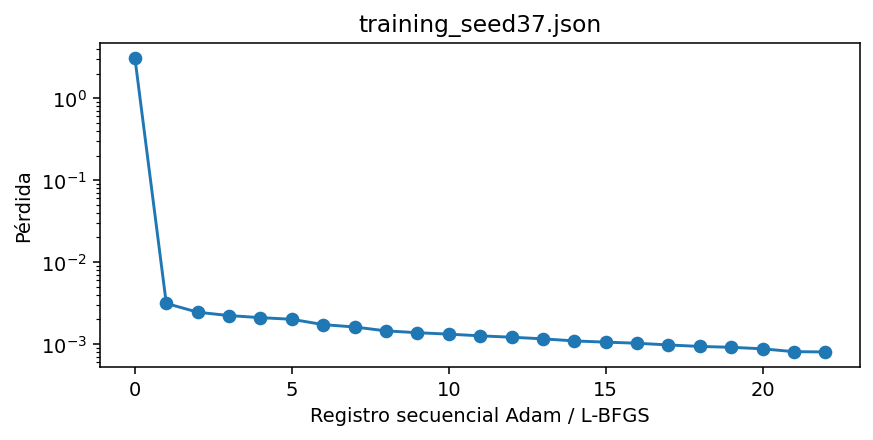

In [6]:
directory=selected_directory(CASE)
for path in sorted(directory.glob('training_seed*.json')):
    r=json.loads(path.read_text())
    h=pd.DataFrame(r['history'])
    display(pd.DataFrame([r['metadata']]).drop(columns=['case'],errors='ignore'))
    if not h.empty:
        fig,ax=plt.subplots(figsize=(7,3))
        ax.semilogy(np.arange(len(h)),h['loss'],'o-')
        ax.set(xlabel='Registro secuencial Adam / L-BFGS',ylabel='Pérdida',title=path.name)
        show_figure(fig);plt.close(fig)

## 8. Alcance de la interpretación

Los fallos permanecen en la tabla. El uso de una configuración seleccionada en
el mismo caso es evidencia de ajuste, no una prueba independiente de
generalización. Los tiempos incluyen procesos concurrentes y dos entornos;
no sustentan una ventaja de velocidad frente a FEM. Las corrientes finales
resuelven el acoplamiento individual R(T) y Tmax = 90 °C. Corresponden a
ampacidades DC del modelo reducido y requieren los criterios adicionales
de residuo eléctrico, temperatura límite y error frente a FEM. Las pérdidas
AC y la validación de una instalación real quedan fuera de esta evidencia.

## Distribución espacial de los parámetros

El gráfico se genera desde la misma especificación que leen ambos métodos.
En MMS la fuente es la derivada de la solución exacta; en cables, Q = 0 en
suelo y la potencia entra por las fronteras. Las fórmulas y los escenarios
manufacturados son de elaboración propia.

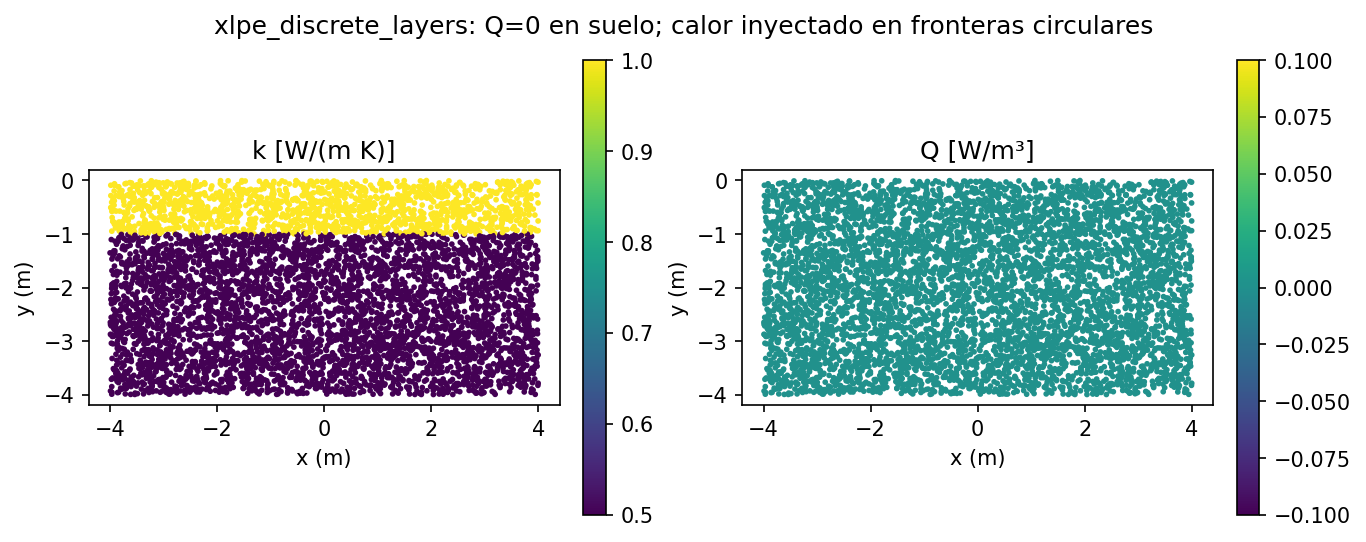

In [7]:
from IPython.display import Image
from Benchmarks.internal_report import material_plot
material_file=ROOT/'Benchmarks/summary/figures'/f'{CASE}_materials.png'
material_file.parent.mkdir(parents=True,exist_ok=True)
if not material_file.exists():material_plot(CASE,material_file)
display(Image(filename=str(material_file)))


## 9. Pérdidas actualizadas y corriente límite

Cada fila conserva temperatura, resistencia y potencia por conductor. La
formulación DC usa CIGRÉ Working Group B1.56 (2022: 132); la reconstrucción
radial, la optimización conjunta y las tolerancias son decisiones del artefacto.
El resultado a R20 fija se muestra como control. La referencia final emplea
FEniCSx con R(T) individual, al igual que PINN.

In [8]:
losses=[]
for filename in ['fem_l2.json','fem_ampacity_l2.json']:
    r=json.loads((ROOT/'Benchmarks/coupled_results'/CASE/filename).read_text())
    for j,(t,p,resistance) in enumerate(zip(r['conductor_C'],r['powers_W_m'],r['resistance_ohm_m'])):
        losses.append(dict(mode='ampacity' if r['ampacity'] else 'nominal',conductor=j,
            current_A=r['current_A'],temperature_C=t,power_W_m=p,resistance_ohm_m=resistance))
display(pd.DataFrame(losses))
fixed=json.loads((ROOT/'Benchmarks/results'/CASE/'fem_l2.json').read_text())
nominal=json.loads((ROOT/'Benchmarks/coupled_results'/CASE/'fem_l2.json').read_text())
display(pd.DataFrame({'modelo':['R20 fija (control)','R(Tc) individual (operación)'],
    'Tmax_C':[fixed['Tmax_C'],nominal['Tmax_C']]}))
display(df[df['mode']!='fixed_source'][['run','seed','mode','current_A','error_current_pct',
    'electrical_residual_pct','temperature_limit_error_K','ampacity_criteria_pass']])
r=json.loads((ROOT/'Benchmarks/coupled_results'/CASE/'fem_ampacity_l2.json').read_text())
display(pd.DataFrame(r['trace']['bisection']))
# Para repetir la búsqueda PINN, se reutiliza la configuración guardada:
RUN_AMPACITY=False
if RUN_AMPACITY:
    saved=sorted(selected_ampacity_directory(CASE).glob('pinn_seed*.json'))[0]
    metadata=json.loads(saved.read_text())['metadata']
    cfg=dict(metadata['configuration']);cfg.update(cases=[CASE],seeds=[11,23,37],output='Benchmarks/reproduced_ampacity')
    path=ROOT/'Benchmarks/notebooks'/f'{CASE}_ampacity_rerun.json'
    path.write_text(json.dumps(cfg,indent=2),encoding='utf-8')
    subprocess.run([sys.executable,str(ROOT/'Benchmarks/pinn.py'),'--config',str(path)],cwd=ROOT,check=True)


,mode,conductor,current_A,temperature_C,power_W_m,resistance_ohm_m
0,nominal,0,270.000000,38.651791,15.101031,0.000207
1,ampacity,0,479.889507,89.999997,56.674025,0.000246


,modelo,Tmax_C
0,R20 fija (control),37.377960
1,R(Tc) individual (operación),38.651791


,run,seed,mode,current_A,error_current_pct,electrical_residual_pct,temperature_limit_error_K,ampacity_criteria_pass
0,ampacity_final/xlpe_discrete_layers,11,ampacity,479.272086,0.128659,0.004700,0.019959,True
1,ampacity_final/xlpe_discrete_layers,23,ampacity,479.523346,0.076301,0.005370,0.014997,True
2,ampacity_final/xlpe_discrete_layers,37,ampacity,479.406140,0.100725,0.006082,0.014929,True
6,coupled_final/xlpe_discrete_layers,11,coupled,270.000000,NaN,0.000160,NaN,None
7,coupled_final/xlpe_discrete_layers,23,coupled,270.000000,NaN,0.001094,NaN,None
8,coupled_final/xlpe_discrete_layers,37,coupled,270.000000,NaN,0.001682,NaN,None


,iteration,current_A,Tmax_C,stable
0,0,270.000000,38.651791,True
1,1,405.000000,66.199664,True
2,2,472.500000,87.295079,True
3,3,506.250000,100.398037,True
4,4,489.375000,93.602946,True
5,5,480.937500,90.390735,True
6,6,476.718750,88.828648,True
7,7,478.828125,89.606089,True
8,8,479.882812,89.997507,True
9,9,480.410156,90.193894,True


## Diagnóstico de las fronteras por separado

El balance total puede ocultar errores que se compensan entre cables. Se
conservan las potencias impuestas e integradas en cada frontera, además del
error local de flujo de PINN. Son diagnósticos adicionales; no se modificó
retrospectivamente el criterio de aceptación. La temperatura empleada en
R(Tc) representa el centro del conductor mediante la reconstrucción radial.

In [9]:
family='coupled_results' if c['kind']=='cable' else 'results'
fem=json.loads((ROOT/'Benchmarks'/family/CASE/'fem_l2.json').read_text())
display(pd.DataFrame(fem.get('boundary_diagnostics',[])))
for path in sorted(selected_directory(CASE).glob('pinn_seed*.json')):
    result=json.loads(path.read_text())
    print(path.name)
    display(pd.DataFrame(result['boundary_diagnostics']))


,boundary,prescribed_heat_into_soil_W_m,computed_heat_into_soil_W_m,relative_power_error_pct
0,cable0,15.101031,15.0693,0.210123


pinn_seed11.json


,boundary,net_outward_heat_W_m,temperature_rmse_K,temperature_max_error_K,prescribed_heat_into_soil_W_m,computed_heat_into_soil_W_m,relative_power_error_pct,flux_rmse_W_m2,flux_max_error_W_m2
0,bottom,1.303760,0.019396,0.041587,NaN,NaN,NaN,NaN,NaN
1,top,13.479596,0.053939,0.107031,NaN,NaN,NaN,NaN,NaN
2,left,-0.042177,0.028665,0.079771,NaN,NaN,NaN,NaN,NaN
3,right,0.359354,0.036566,0.066925,NaN,NaN,NaN,NaN,NaN
4,cable0,-15.100528,NaN,NaN,15.10057,15.100528,0.00028,0.006102,0.012629


pinn_seed23.json


,boundary,net_outward_heat_W_m,temperature_rmse_K,temperature_max_error_K,prescribed_heat_into_soil_W_m,computed_heat_into_soil_W_m,relative_power_error_pct,flux_rmse_W_m2,flux_max_error_W_m2
0,bottom,0.871413,0.057722,0.126467,NaN,NaN,NaN,NaN,NaN
1,top,13.887167,0.043420,0.090535,NaN,NaN,NaN,NaN,NaN
2,left,0.351601,0.027829,0.047600,NaN,NaN,NaN,NaN,NaN
3,right,-0.012415,0.037523,0.126989,NaN,NaN,NaN,NaN,NaN
4,cable0,-15.097268,NaN,NaN,15.097299,15.097268,0.000203,0.00263,0.004913


pinn_seed37.json


,boundary,net_outward_heat_W_m,temperature_rmse_K,temperature_max_error_K,prescribed_heat_into_soil_W_m,computed_heat_into_soil_W_m,relative_power_error_pct,flux_rmse_W_m2,flux_max_error_W_m2
0,bottom,1.268235,0.038005,0.080483,NaN,NaN,NaN,NaN,NaN
1,top,13.414346,0.048860,0.130364,NaN,NaN,NaN,NaN,NaN
2,left,0.230934,0.018504,0.045257,NaN,NaN,NaN,NaN,NaN
3,right,0.183648,0.050949,0.130785,NaN,NaN,NaN,NaN,NaN
4,cable0,-15.096732,NaN,NaN,15.096735,15.096732,0.000015,0.008142,0.01416


## Análisis numérico de error y resolución

Se distinguen capacidad de red, colocaciones y optimización (De Ryck y
Mishra, 2024: 24–27, 51–57). Las cotas de error necesitan hipótesis de
estabilidad y cuadratura (Mishra y Molinaro, 2020: 7–8). El orden FEM se
estima frente a una solución exacta cuando existe refinamiento uniforme.
Las pendientes PINN son empíricas; no se aplica GCI a las neuronas.

La propagación electrotérmica es una derivación propia para la matriz FEM
y la ley R(T) comunes. Se separan los aportes térmico y eléctrico y se
comprueba la identidad vectorial. No se atribuye incertidumbre probabilística
a propiedades físicas sin mediciones.

In [10]:
analysis=json.loads((ROOT/'Benchmarks/summary/numerical_analysis.json').read_text())
for key in ['fem_orders','exact_error_budget','amplification','error_decomposition','mesh_propagation']:
    data=[r for r in analysis[key] if r['case']==CASE]
    if data:
        print(key)
        display(pd.DataFrame(data))
if CASE in ['mms_smooth_2d','xlpe_single']:
    for key in ['resolution','resolution_stability','empirical_slopes']:
        print(key)
        display(pd.DataFrame([r for r in analysis[key] if r['case']==CASE]))
    from IPython.display import Image
    display(Image(filename=str(ROOT/'Tesis_LaTeX_Borrador_UNI/imagenes/benchmarks'/f'{CASE}_resolution.png')))


amplification


,case,amplification_inf,condition_inf,spectral_radius
0,xlpe_discrete_layers,1.073302,1.0,0.068295


error_decomposition


,case,seed,thermal_contribution_K,electrical_contribution_K,actual_temperature_error_K,decomposition_error_K,norm_upper_bound_K
0,xlpe_discrete_layers,11,0.007857,0.000032,0.007889,6.172491e-12,0.007889
1,xlpe_discrete_layers,23,0.070698,0.000219,0.070479,6.172299e-12,0.070917
2,xlpe_discrete_layers,37,0.082622,0.000337,0.082286,6.166845e-12,0.082959


mesh_propagation


,case,mesh_temperature_change_K,linearized_temperature_change_K,linearization_remainder_K,mesh_current_change_A,linearized_current_change_A,current_remainder_A,active_conductors,tangent_central_difference_error_K
0,xlpe_discrete_layers,0.001018,0.001018,3.795994e-09,0.0122,0.0122,4.652530e-07,[0],2.932747e-13


## Referencias

Baratta, I. A., Dean, J. P., Dokken, J. S., Habera, M., Hale, J. S., Richardson, C. N., Rognes, M. E., Scroggs, M. W., Sime, N., & Wells, G. N. (2023). *DOLFINx: The next generation FEniCS problem solving environment* [Prepublicación, versión 1]. Zenodo. https://doi.org/10.5281/zenodo.10447666

CIGRÉ Working Group B1.56. (2022). *Power cable rating examples for calculation tool verification* (Technical Brochure No. 880). CIGRÉ.

CIGRÉ Working Group B1.87. (2025). *Finite element analysis for cable rating calculations* (Technical Brochure No. 963). CIGRÉ.

De Ryck, T., & Mishra, S. (2024). *Numerical analysis of physics-informed neural networks and related models in physics-informed machine learning* [Prepublicación, versión 1]. arXiv. https://arxiv.org/abs/2402.10926v1

Mishra, S., & Molinaro, R. (2020). *Estimates on the generalization error of physics informed neural networks (PINNs) for approximating PDEs* [Prepublicación, versión 1]. arXiv. https://arxiv.org/abs/2006.16144v1

Raissi, M., Perdikaris, P., & Karniadakis, G. E. (2017). *Physics informed deep learning (Part I): Data-driven solutions of nonlinear partial differential equations* [Prepublicación, versión 1]. arXiv. https://arxiv.org/abs/1711.10561

Shukla, K., Jagtap, A. D., & Karniadakis, G. E. (2021). Parallel physics-informed neural networks via domain decomposition. *Journal of Computational Physics, 447*, Article 110683. https://doi.org/10.1016/j.jcp.2021.110683 (Versión consultada: https://arxiv.org/abs/2104.10013v3).

Wang, S., Teng, Y., & Perdikaris, P. (2020). *Understanding and mitigating gradient pathologies in physics-informed neural networks* [Prepublicación, versión 1]. arXiv. https://arxiv.org/abs/2001.04536